# T009 · 基于配体的药效团

**注意：** 本教程是 TeachOpenCADD 的一部分，该平台旨在教授特定领域技能，并为研究项目提供管道模板作为起点。

作者：

- Dominique Sydow, 2019-2020, [Volkamer lab, Charité](https://volkamerlab.org/)
- Andrea Volkamer, 2020, [Volkamer lab, Charité](https://volkamerlab.org/)
- Yonghui Chen, 2020, [Volkamer lab, Charité](https://volkamerlab.org/)
- Mareike Wiedmann, CADD seminar, 2018, Charité/FU Berlin

__教程 T009__：本教程是 [首篇 TeachOpenCADD 论文](https://jcheminf.biomedcentral.com/articles/10.1186/s13321-019-0351-x) 中描述的 TeachOpenCADD 流程的一部分，包括 T001-T010 教程。

**注意**：请逐个单元格运行本 notebook。也可以一次运行所有单元格，但部分 nglview 的 3D 显示可能无法正常渲染。

## 本教程目标

在本教程中，我们使用在前一个教程中选定并对齐的已知 EGFR 配体来生成基于配体的药效团。由此产生的药效团模型可用于虚拟筛选（VS），以识别潜在的新 EGFR 配体。

## 学习目标

### 理论内容

* 药效团建模
    * 基于结构和基于配体的药效团建模
* 虚拟筛选与药效团
* 聚类：k-means

### 实践内容

* 从上一个教程获取预对齐的配体
* 使用 NGLView 展示配体
* 提取药效团特征
* 显示所有配体的药效团特征
* 按特征类型收集特征的坐标
* 生成整合药效团（通过 k-means 聚类）
* 显示聚类结果
* 显示整合药效团

### 参考文献

* IUPAC 药效团定义（[<i>Pure & Appl. Chem</i> (1998), <b>70</b>, 1129-43](https://www.degruyter.com/view/journals/pac/70/5/article-p1129.xml)）
* 药效团建模综述（[<i>Int. J. Mol. Sci.</i> (2019), <b>20(23)</b>, 1-23](https://www.mdpi.com/1661-6596/20/23/5874)）
* 关于药效团的三部分系列博文：
    * [药效团建模介绍](https://blog.mol2vec.com/an-introduction-to-pharmacophore-modeling/)
    * [从配体到药效团：使用 RDKit](https://blog.mol2vec.com/from-ligand-to-pharmacophore-using-rdkit/)
    * [虚拟筛选与药效团](https://blog.mol2vec.com/virtual-screening-with-pharmacophores/)
* k-means 聚类
    * [k-means 聚类（Wikipedia）](https://en.wikipedia.org/wiki/K-means_clustering)
    * [k-means 聚类的 ELKI 教程](https://elki-project.github.io/tutorial/kmeans)

In [1]:
import sys

if "google.colab" in sys.modules:
    %pip install teachopencadd --no-deps -q
    !teachopencadd -d 9
    %pip uninstall teachopencadd -y -q
    %pip install -qr requirements.txt

## 理论

### 药效团

在计算机辅助药物设计中，用药效团描述药物-靶标相互作用是一种流行的相互作用筛选方法。IUPAC 将药效团定义为"空间和电子特征的集合，这些特征是确保与特定生物靶标结构实现最佳超分子相互作用并触发（或阻断）其生物学响应所必需的"。换句话说，药效团模型包含了配体有效结合生物靶标并触发生物学效应所需的所有特征（例如，氢键供体、氢键受体、疏水接触或芳环）。此外，这些特征在空间上是排列的；因此药效团模型不仅是特征类型的集合，也是特征的三维排列。

### 基于结构和基于配体的药效团建模

在药效团建模中，根据可用信息使用两种主要方法：
- **基于结构**的药效团模型：使用蛋白质的 3D 结构来研究可能的配体相互作用，并推导出可被给定配体填充的"有利"特征位置。
- **基于配体**的药效团模型：如果蛋白质的 3D 结构未知，而是使用了一组已知结合该蛋白质的配体，则可以使用该配体集推导出药效团模型。

一种特殊情况（用于本教程）是从一组已知结合特定靶标的配体中推导药效团模型，从而产生基于配体的药效团模型。在我们的教程中，我们将生成一个_整合_药效团：通过聚类方法（如 k-means）从一组配体中推导出药效团模型。

### 使用药效团进行虚拟筛选

如**教程 4**中所述，虚拟筛选（VS）描述了使用计算模型自动筛选大型化合物数据库，以寻找新的药物候选物（即命中化合物）。药效团可用于虚拟筛选：筛选候选化合物中的药效团特征是否与我们预测的药效团模型匹配（3D 匹配）。匹配度以 RMSD 值衡量（RMSD 值越低，匹配度越高）。

### 聚类：k-means

在本教程中，我们将通过结合配体集中每类药效团特征的特征点（例如，所有配体的所有供体特征）进行聚类，并使用 k-means 聚类推导出特征中心，从而生成整合药效团。

k-means 聚类是一种无监督的机器学习算法，旨在将数据划分为 k 个簇，其中每个数据点属于具有最近均值（也称为质心）的簇。有关 k-means 更详细的说明，请参阅 [k-means 聚类文档](https://scikit-learn.org/stable/modules/clustering.html#k-means)。

一个主要问题是_如何选择 k_（即簇的数量）。虽然没有通用的选择 k 的方法，但我们可以使用一些因子来指导我们的决定：
- 数据点的数量（我们有多少个供体/受体/疏水特征）和特征类型（供体、受体、疏水接触）
- 预期的簇大小
- 簇的数量

在实用部分中，我们将设置参数 `kq`，它将根据数据点的数量确定 k：

$$k = \frac{\text{number of data points}}{kq}$$

## 实践

In [2]:
import collections
from collections import Counter
from pathlib import Path
import operator
import time
import math

import pandas as pd
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
from sklearn import datasets, cluster

from rdkit import RDConfig, Chem, Geometry, DistanceGeometry
from rdkit.Chem import ChemicalFeatures, rdDistGeom, Draw, rdMolTransforms, AllChem

# from rdkit.Chem.Draw import DrawingOptions
from rdkit.Chem.Pharm3D import Pharmacophore, EmbedLib
from rdkit.Numerics import rdAlignment
import nglview as nv

设置当前 notebook 的路径。

In [3]:
HERE = Path(_dh[-1])
DATA = HERE / "data"

### 从上一个教程获取预对齐的配体

我们检索在**教程 T008**中对齐的所有配体。预对齐很重要，因为我们将在这些配体上提取特征：只有预对齐的配体才能做到这一点，否则 3D 坐标将不具有可比性。

In [4]:
mol_files = sorted(Path(DATA / "T008_data").glob("*_lig.pdb"))
print([f.name for f in mol_files])

['5HG8_lig.pdb', '5UG8_lig.pdb', '5UG9_lig.pdb', '5UGC_lig.pdb']


In [5]:
# NBVAL_CHECK_OUTPUT
pdb_ids = [Path(file).stem.split("_")[0] for file in mol_files]
pdb_ids

['5HG8', '5UG8', '5UG9', '5UGC']

其次，我们使用 RDKit 从这些 PDB 文件中读取所有配体。

In [6]:
# NBVAL_CHECK_OUTPUT
molecules = []
for mol_file in mol_files:
    molecule = Chem.MolFromPDBFile(str(mol_file), removeHs=False)
    if molecule is None:
        print(mol_file, "Could not be read")
    else:
        Chem.SanitizeMol(molecule)
        print(Chem.MolToSmiles(molecule))
        molecules.append(molecule)
print(f"Number of molecules: {len(molecules)}")

CCC(O)NC1CCCC(OC2NC(NC3CNN(C)C3)NC3NCCC32)C1
CCC(O)NC1CN(C2NC(NC3CNN(C)C3)C3NCN(C(C)C)C3N2)CC1F
CCC(O)NC1CN(C2NC(NC3CN(C)NC3OC)C3NCN(C(C)C)C3N2)CC1F
CCC(O)NC1CN(C2NC(NC3CN(C)NC3OC)C3NCN(C)C3N2)CC1F
Number of molecules: 4


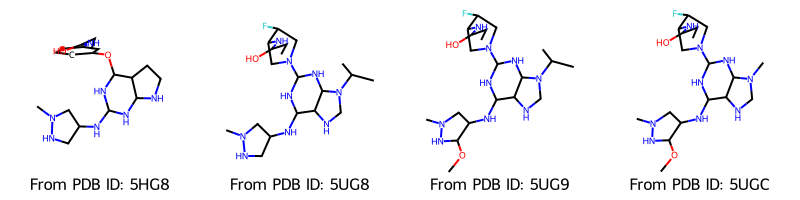

In [7]:
Draw.MolsToGridImage(
    molecules,
    molsPerRow=4,
    legends=[f"From PDB ID: {pdb_id}" for pdb_id in pdb_ids],
)

在检查结构时，我们注意到这里遇到了一个问题：当从 PDB 文件加载配体时，RDKit 无法正确分配键序。我们可以通过使用配体的 SMILES 模式来修正这一点，即我们通过 SMILES 模式分配正确的键序，同时从 PDB 文件保留 3D 坐标。

In [8]:
# Load SMILES for PDB ligand structures
ligands = pd.read_csv(DATA / "PDB_top_ligands.csv")

# Get SMILES in the same order as in pdb_ids
ligand_smiles = [
    ligands[ligands["@structureId"] == pdb_id]["smiles"].values[0] for pdb_id in pdb_ids
]

# Generate RDKit Mol object from SMILES
reference_molecules = [Chem.MolFromSmiles(smiles) for smiles in ligand_smiles]

# Assign bond orders to molecules based on SMILES patterns of reference molecules
molecules = [
    AllChem.AssignBondOrdersFromTemplate(reference_molecule, molecule)
    for reference_molecule, molecule in zip(reference_molecules, molecules)
]

[11:09:33] WARNING: More than one matching pattern found - picking one

[11:09:33] WARNING: More than one matching pattern found - picking one



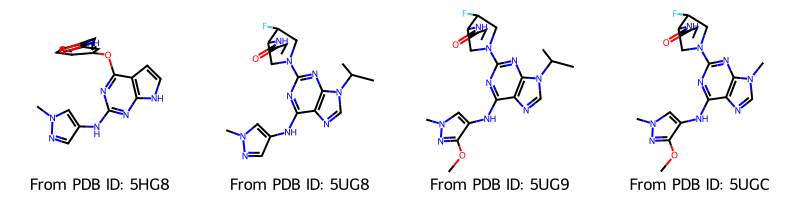

In [9]:
Draw.MolsToGridImage(
    molecules,
    molsPerRow=4,
    legends=[f"From PDB ID: {pdb_id}" for pdb_id in pdb_ids],
)

现在包含了正确的键。我们还可以在 2D 中查看分子。为了保留原始坐标，我们将创建分子的副本（没有 3D 坐标的分子）。

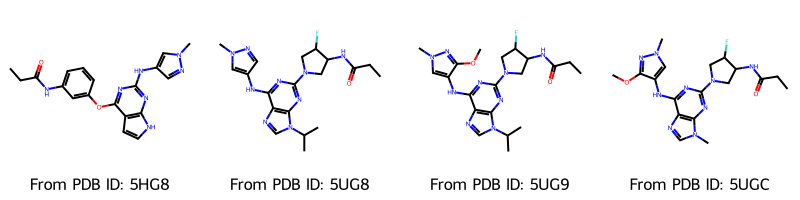

In [10]:
molecules_2d = []
for molecule in molecules:
    tmp = Chem.Mol(molecule)
    AllChem.Compute2DCoords(tmp)
    molecules_2d.append(tmp)
Draw.MolsToGridImage(
    molecules_2d,
    molsPerRow=4,
    legends=[f"From PDB ID: {pdb_id}" for pdb_id in pdb_ids],
)

### 使用 `nglview` 可视化

在下一步中，我们使用以下函数通过 nglview 可视化配体分子。分子将以线条表示形式绘制，碳原子以不同的颜色着色。

In [11]:
def show_ligands(molecules):
    """Generate a view of the ligand molecules.

    Parameters
    -----------
    molecules: list of rdkit.Chem.rdchem.Mol

    Returns
    ----------
    nglview.widget.NGLWidget
    """
    view = nv.NGLWidget()
    for molecule in molecules:
        component = view.add_component(molecule)
        time.sleep(0.1)
        component.clear()
        component.add_ball_and_stick(multipleBond=True)
    return view

In [12]:
view = show_ligands(molecules)
view

NGLWidget()

In [13]:
view.render_image(trim=True, factor=2, transparent=True);

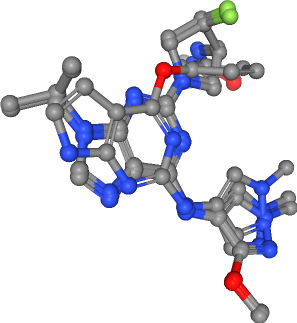

In [14]:
view._display_image()

### 提取药效团特征

如上所述，本教程的目标是生成基于配体的整合药效团。为此，我们首先需要提取配体集中所有分子的药效团特征。请注意，正确分配键序对此步骤非常重要；否则将无法提取药效团特征。

In [15]:
feature_factory = AllChem.BuildFeatureFactory(str(Path(RDConfig.RDDataDir) / "BaseFeatures.fdef"))

我们来看看 RDKit 中实现的药效团特征：

In [16]:
list(feature_factory.GetFeatureDefs().keys())

['Donor.SingleAtomDonor',
 'Acceptor.SingleAtomAcceptor',
 'NegIonizable.AcidicGroup',
 'PosIonizable.BasicGroup',
 'PosIonizable.PosN',
 'PosIonizable.Imidazole',
 'PosIonizable.Guanidine',
 'ZnBinder.ZnBinder1',
 'ZnBinder.ZnBinder2',
 'ZnBinder.ZnBinder3',
 'ZnBinder.ZnBinder4',
 'ZnBinder.ZnBinder5',
 'ZnBinder.ZnBinder6',
 'Aromatic.Arom4',
 'Aromatic.Arom5',
 'Aromatic.Arom6',
 'Aromatic.Arom7',
 'Aromatic.Arom8',
 'Hydrophobe.ThreeWayAttach',
 'Hydrophobe.ChainTwoWayAttach',
 'LumpedHydrophobe.Nitro2',
 'LumpedHydrophobe.RH6_6',
 'LumpedHydrophobe.RH5_5',
 'LumpedHydrophobe.RH4_4',
 'LumpedHydrophobe.RH3_3',
 'LumpedHydrophobe.tButyl',
 'LumpedHydrophobe.iPropyl']

例如，我们从第一个分子中提取所有特征。

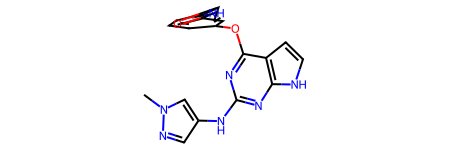

In [17]:
example_molecule = molecules[0]
example_molecule

In [18]:
# NBVAL_CHECK_OUTPUT
features = feature_factory.GetFeaturesForMol(example_molecule)
print(f"Number of features found: {len(features)}")

Number of features found: 16


特征的类型在 RDKit 中称为族（family），可以通过 `GetFamily()` 获取。

In [19]:
# NBVAL_CHECK_OUTPUT
features[0].GetFamily()

'Donor'

首先获取示例分子的特征类型频率。

In [20]:
# NBVAL_CHECK_OUTPUT
feature_frequency = collections.Counter(sorted([feature.GetFamily() for feature in features]))
feature_frequency

Counter({'Acceptor': 5,
         'Aromatic': 4,
         'Donor': 4,
         'Hydrophobe': 2,
         'LumpedHydrophobe': 1})

现在将上述函数应用于配体集中所有分子。我们计算每个分子的特征类型频率，同时也收集每个分子的特征类型坐标。

In [21]:
molecule_feature_frequencies = []
for molecule in molecules:
    features = [feature.GetFamily() for feature in feature_factory.GetFeaturesForMol(molecule)]
    feature_frequency = collections.Counter(features)
    molecule_feature_frequencies.append(feature_frequency)

feature_frequencies_df = (
    pd.DataFrame(
        molecule_feature_frequencies,
        index=[f"Mol{i}" for i, _ in enumerate(molecules, 1)],
    )
    .fillna(0)
    .astype(int)
)
feature_frequencies_df.transpose()

,Mol1,Mol2,Mol3,Mol4
Donor,4,2,2,2
Acceptor,5,6,7,7
Aromatic,4,3,3,3
Hydrophobe,2,1,1,1
LumpedHydrophobe,1,1,1,0
PosIonizable,0,1,1,1


进一步，本教程仅关注以下特征类型：氢键受体、氢键供体和疏水接触。

In [22]:
acceptors = []
donors = []
hydrophobics = []

for molecule in molecules:
    acceptors.append(feature_factory.GetFeaturesForMol(molecule, includeOnly="Acceptor"))
    donors.append(feature_factory.GetFeaturesForMol(molecule, includeOnly="Donor"))
    hydrophobics.append(feature_factory.GetFeaturesForMol(molecule, includeOnly="Hydrophobe"))

features = {
    "donors": donors,
    "acceptors": acceptors,
    "hydrophobics": hydrophobics,
}

### 显示所有配体的药效团特征

药效团特征类型通常以定义的颜色显示。在下表中，列出了本教程中使用的颜色方案（符合常见的着色标准）。

In [23]:
feature_colors = {
    "donors": (0, 0.9, 0),  # Green
    "acceptors": (0.9, 0, 0),  # Red
    "hydrophobics": (1, 0.9, 0),  # Yellow
}

In [24]:
def visualize_features(
    molecules,
    features,
    feature_type="features",
    color="yellow",
    sphere_radius=0.5,
):
    """Generate a view of the molecules highlighting the specified feature type.

    Parameters
    -----------
    molecules: list of rdkit.Chem.rdchem.Mol
        molecules to be visualized
    features: list of tuples of rdkit.Chem.rdMolChemicalFeatures.MolChemicalFeature
        extracted features from molecules chosen to be highlighted
    feature_type: string, optional
        name of the feature to be highlighted
    color: string, optional
        color used to display the highlighted features
    sphere_radius: float, optional
        display size of the highlighted features

    Returns
    ----------
    nglview.widget.NGLWidget
    """
    print(f"Number of {feature_type} in all ligands: {sum([len(i) for i in features])}")
    view = show_ligands(molecules)
    for i, feature_set in enumerate(features, 1):
        for feature in feature_set:
            loc = list(feature.GetPos())
            label = f"{feature_type}_{i}"
            view.shape.add_sphere(loc, color, sphere_radius, label)
    return view

我们使用此函数来可视化所考虑特征类型的特征。

#### 氢键供体

In [25]:
feature_type = "donors"
view = visualize_features(
    molecules,
    features[feature_type],
    feature_type,
    feature_colors[feature_type],
)
view

Number of donors in all ligands: 10


NGLWidget()

In [26]:
view.render_image(trim=True, factor=2, transparent=True);

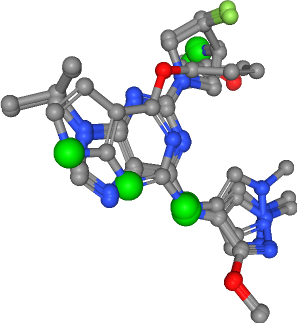

In [27]:
view._display_image()

#### 氢键受体

In [28]:
feature_type = "acceptors"
view = visualize_features(
    molecules,
    features[feature_type],
    feature_type,
    feature_colors[feature_type],
)
view

Number of acceptors in all ligands: 25


NGLWidget()

In [29]:
view.render_image(trim=True, factor=2, transparent=True);

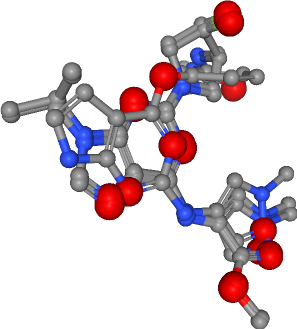

In [30]:
view._display_image()

#### 疏水接触

In [31]:
feature_type = "hydrophobics"
view = visualize_features(
    molecules,
    features[feature_type],
    feature_type,
    feature_colors[feature_type],
)
view

Number of hydrophobics in all ligands: 5


NGLWidget()

In [32]:
view.render_image(trim=True, factor=2, transparent=True);

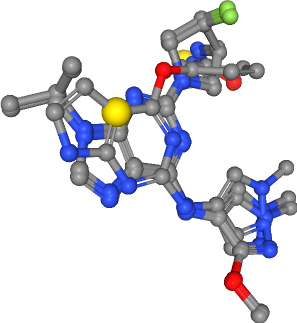

In [33]:
view._display_image()

### 按特征类型收集特征的坐标

我们希望按特征类型对特征进行聚类。为此，我们收集每种特征类型的特征坐标。

In [34]:
features_coord = {
    "donors": [list(item.GetPos()) for sublist in features["donors"] for item in sublist],
    "acceptors": [list(item.GetPos()) for sublist in features["acceptors"] for item in sublist],
    "hydrophobics": [
        list(item.GetPos()) for sublist in features["hydrophobics"] for item in sublist
    ],
}

现在，我们有了例如所有受体特征的位置：

In [35]:
features_coord["acceptors"]

[[-13.49, 14.732, -27.925],
 [-11.99, 13.164, -28.961],
 [-13.173, 17.112, -28.025],
 [-16.131, 17.359, -22.003],
 [-16.873, 11.631, -25.856],
 [-13.808, 14.802, -27.137],
 [-12.146, 16.255, -28.067],
 [-11.385, 12.957, -29.278],
 [-16.736, 10.854, -25.879],
 [-15.435, 19.394, -27.21],
 [-16.039, 17.251, -22.54],
 [-13.863, 14.66, -27.134],
 [-12.175, 16.118, -27.994],
 [-11.411, 12.856, -29.266],
 [-17.026, 10.809, -26.396],
 [-15.601, 9.901, -28.086],
 [-15.445, 19.229, -27.215],
 [-16.044, 17.165, -22.506],
 [-13.831, 14.581, -27.162],
 [-12.161, 16.037, -28.079],
 [-11.381, 12.733, -29.268],
 [-17.02, 10.739, -26.48],
 [-15.542, 9.814, -28.111],
 [-15.515, 19.1, -27.334],
 [-16.09, 17.203, -22.553]]

### 生成整合药效团

为了生成整合药效团，我们使用 k-means 聚类对每种特征类型的特征点进行聚类，从最大的簇中选择簇中心，并将其用作整合药效团特征。

#### 设置 k-means 聚类的静态参数

* `kq`：使用此参数，我们根据数据点的数量确定簇的数量 `k`：$k = \frac{\text{number of data points}}{kq}$

In [36]:
kq = 7

#### 设置聚类选择的静态参数

* `min_cluster_size`：我们只想保留可能代表药效团特征的簇。因此，我们允许指定一个最小簇大小，作为数据点总数的百分比。

In [37]:
min_cluster_size = int(len(molecules) * 0.75)
top_cluster_number = 4

#### 定义 k-means 聚类和聚类选择函数

我们定义一个函数，计算每种特征类型的特征点簇中心。

In [38]:
def clustering(feature_coord, kq):
    """
    Compute the k-means clustering of input feature coordinates.

    Parameters
    -----------
    feature_coord: list
        feature coordinates extracted from the features of a set of molecules
    kq: int
        Quotient used when calculating number of features k

    Returns
    ----------
    sklearn.cluster._kmeans.KMeans
    """
    # Define parameter k as feature number divided by "k quotient"
    k = math.ceil(len(feature_coord) / kq)
    # Tailor-made adaption of k for hydrophobics in for the example in this talktorial
    k = 2 if k == 1 else k
    print(f"Clustering: \nVariable k in k-means: {k} of {len(feature_coord)} points\n")

    # Initialize k-means and compute clustering
    k_means = cluster.KMeans(n_clusters=k, n_init=10)
    k_means.fit(feature_coord)

    return k_means

我们定义一个函数，按大小排序簇，并输出最大簇的索引列表。

In [39]:
def get_clusters(k_means, min_cluster_size, top_cluster_number):
    """
    Select clusters from a k-means clustering and returns the indices of the selected clusters.
    The selection is based on cluster size. The largest clusters are chosen.

    Parameters
    -----------
    k_means: sklearn.cluster._kmeans.KMeans
        k-means clustering of feature coordinates
    min_cluster_size: int
        minimum size needed for a cluster to be viable for selection
    top_cluster_number: int
        number of clusters to be selected

    Returns
    ----------
    list of int
        indices of selected clusters
    """

    # Sort clusters by size and only show largest
    feature_labels = k_means.labels_

    feature_labels_count = Counter(feature_labels)

    feature_labels_count = sorted(
        feature_labels_count.items(), key=operator.itemgetter(1), reverse=True
    )
    print(f"Clusters sorted by size: \n{feature_labels_count}\n")

    # Get number of the largest clusters, which are larger then the threshold (selected clusters)
    cluster_indices_sel = []

    for cluster_index, cluster_size in feature_labels_count:
        if cluster_size >= min_cluster_size and top_cluster_number > 0:
            cluster_indices_sel.append(cluster_index)
            top_cluster_number -= 1

    print(f"Cluster indices of selected clusters: \n{cluster_indices_sel}\n")

    return cluster_indices_sel

#### 聚类特征

对于每种特征类型，我们使用定义的 `clustering` 函数执行 k-means 聚类。

In [40]:
k_means = {
    "donors": clustering(features_coord["donors"], kq),
    "acceptors": clustering(features_coord["acceptors"], kq),
    "hydrophobics": clustering(features_coord["hydrophobics"], kq),
}

Clustering: 
Variable k in k-means: 2 of 10 points

Clustering: 
Variable k in k-means: 4 of 25 points

Clustering: 
Variable k in k-means: 2 of 5 points



#### 选择相关簇

对于每种特征类型，我们使用定义的 `get_clusters` 函数选择相关簇。

In [41]:
print("Hydrogen bond donors\n")
cluster_indices_sel_donors = get_clusters(k_means["donors"], min_cluster_size, top_cluster_number)

Hydrogen bond donors

Clusters sorted by size: 
[(np.int32(0), 6), (np.int32(1), 4)]

Cluster indices of selected clusters: 
[np.int32(0), np.int32(1)]



In [42]:
print("Hydrogen bond acceptors\n")
cluster_indices_sel_acceptors = get_clusters(
    k_means["acceptors"], min_cluster_size, top_cluster_number
)

Hydrogen bond acceptors

Clusters sorted by size: 
[(np.int32(2), 12), (np.int32(0), 6), (np.int32(3), 4), (np.int32(1), 3)]

Cluster indices of selected clusters: 
[np.int32(2), np.int32(0), np.int32(3), np.int32(1)]



In [43]:
print("Hydrophobic contacts\n")
cluster_indices_sel_hydrophobic = get_clusters(
    k_means["hydrophobics"], min_cluster_size, top_cluster_number
)

Hydrophobic contacts

Clusters sorted by size: 
[(np.int32(0), 4), (np.int32(1), 1)]

Cluster indices of selected clusters: 
[np.int32(0)]



In [44]:
cluster_indices_sel = {
    "donors": cluster_indices_sel_donors,
    "acceptors": cluster_indices_sel_acceptors,
    "hydrophobics": cluster_indices_sel_hydrophobic,
}

#### 获取选定簇的坐标

In [45]:
def get_selected_cluster_center_coords(k_means, cluster_indices_sel):
    """Retrieve cluster center coordinates for selected clusters.
    The selected clusters are defined by their indices.

    Parameters
    -----------
    k_means: sklearn.cluster._kmeans.KMeans
        k-means clustering of feature coordinates
    cluster_indices_sel: list of int
        indices of the chosen clusters

    Returns
    ----------
    two-dimensional list of floats
        cluster center coordinates
    """
    cluster_centers = k_means.cluster_centers_

    # Cast to list and then to pandas Series (for element selection by indices)
    cluster_centers = pd.Series(cluster_centers.tolist())

    # Select cluster centers by indices of selected clusters
    cluster_centers_sel = cluster_centers[cluster_indices_sel]

    return list(cluster_centers_sel)

In [46]:
cluster_centers_sel = {
    "donors": get_selected_cluster_center_coords(k_means["donors"], cluster_indices_sel["donors"]),
    "acceptors": get_selected_cluster_center_coords(
        k_means["acceptors"], cluster_indices_sel["acceptors"]
    ),
    "hydrophobics": get_selected_cluster_center_coords(
        k_means["hydrophobics"], cluster_indices_sel["hydrophobics"]
    ),
}

In [47]:
cluster_centers_sel["acceptors"]

[[-12.567833333333333, 14.66725, -28.191333333333333],
 [-16.466333333333335, 10.624666666666666, -26.801333333333332],
 [-16.076, 17.244500000000002, -22.4005],
 [-15.465, 19.241, -27.253]]

### 显示聚类结果

对于每种特征类型，我们可视化簇中心以及所有分子和所有特征点。

In [48]:
def visualize_clusters(
    molecules,
    features,
    clusters,
    feature_type="features",
    color="yellow",
    feature_radius=0.5,
    cluster_radius=1,
):
    """Visualize the cluster centers.

    Parameters
    -----------
     molecules: list of rdkit.Chem.rdchem.Mol
        molecules to be visualized
    features: list of tuples of rdkit.Chem.rdMolChemicalFeatures.MolChemicalFeature
        extracted features from molecules chosen to be highlighted
    clusters: Two-dimensional list of floats
        cluster center coordinates
    feature_type: string, optional
        feature type being visualized
    color: string, optional
        color used for rendering the features and cluster centers
    feature_radius: float, optional
        rendering size of the features
    cluster_radius: float, optional
        rendering size of the cluster centers

    Returns
    ----------
    nglview.widget.NGLWidget
    """
    view = visualize_features(
        molecules,
        features,
        feature_type,
        color=color,
        sphere_radius=feature_radius,
    )
    for i, center in enumerate(clusters, 1):
        view.shape.add_sphere(list(center), color, cluster_radius, f"cluster_{feature_type}_{i}")
    return view

#### 氢键供体

In [49]:
feature_type = "donors"
view = visualize_clusters(
    molecules,
    features[feature_type],
    cluster_centers_sel[feature_type],
    feature_type,
    feature_colors[feature_type],
)
view

Number of donors in all ligands: 10


NGLWidget()

In [50]:
view.render_image(trim=True, factor=2, transparent=True);

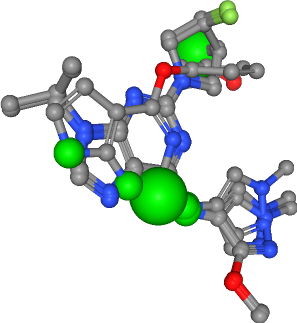

In [51]:
view._display_image()

#### 氢键受体

In [52]:
feature_type = "acceptors"
view = visualize_clusters(
    molecules,
    features[feature_type],
    cluster_centers_sel[feature_type],
    feature_type,
    feature_colors[feature_type],
)
view

Number of acceptors in all ligands: 25


NGLWidget()

In [53]:
view.render_image(trim=True, factor=2, transparent=True);

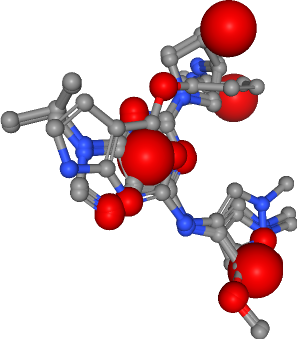

In [55]:
view._display_image()

#### 疏水接触

In [56]:
feature_type = "hydrophobics"
view = visualize_clusters(
    molecules,
    features[feature_type],
    cluster_centers_sel[feature_type],
    feature_type,
    feature_colors[feature_type],
)
view

Number of hydrophobics in all ligands: 5


NGLWidget()

In [57]:
view.render_image(trim=True, factor=2, transparent=True);

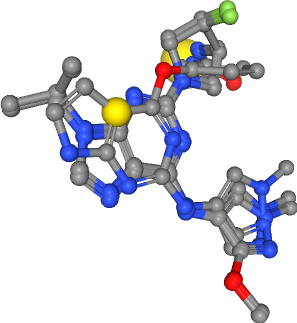

In [58]:
view._display_image()

### 显示整合药效团

在最后一步中，我们将聚集的药效团特征（即氢键供体、氢键受体和疏水接触）合并到一个整合药效团中。

In [59]:
view = show_ligands(molecules)
# Load clusters
for feature_type in cluster_indices_sel.keys():
    centers = cluster_centers_sel[feature_type]
    for i, loc in enumerate(centers):
        sphere_radius = 1
        feature_color = feature_colors[feature_type]
        label = f"{feature_type}_c{i}"
        view.shape.add_sphere(loc, feature_color, sphere_radius, label)
view

NGLWidget()

In [60]:
view.render_image(trim=True, factor=2, transparent=True);

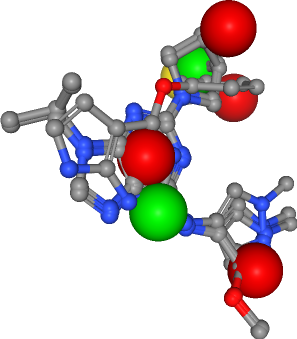

In [61]:
view._display_image()

## 讨论

在本教程中，我们使用了一组已知结合 EGFR 的预对齐配体来生成一个整合药效团。我们通过提取（供体、受体和疏水接触的）特征、按特征类型使用 k-means 进行聚类，并选择最大的簇作为最终药效团特征来推导出药效团。现在，这个整合药效团可用于虚拟筛选，以识别可能结合 EGFR 的新分子。

在下一个教程（**T010**）中，我们将利用结构相似性来预测配体的可能脱靶效应。